# LSDL CUB, seminar 01. Linear probing, fine-tuning & zero-shot

**Attention!** To run this notebook, put files `scatter_plot.py` from the repo in the same directory. Also replace `cifar10.py` and `common.py` from `src/datasets/` with the new versions from the repo.

In [ ]:
%%bash

git clone https://github.com/mlfoundations/wise-ft.git
mv wise-ft/* .
mv src/wise_ft.py .
mv src/scatter_plot.py .

pip install ftfy wilds
pip install git+https://github.com/modestyachts/ImageNetV2_pytorch

rm scatter_plot.py
wget https://github.com/isadrtdinov/lsdl-cub/raw/refs/heads/2025/week01-finetune/seminar/scatter_plot.py
wget https://github.com/isadrtdinov/lsdl-cub/raw/refs/heads/2025/week01-finetune/seminar/cifar10.py
wget https://github.com/isadrtdinov/lsdl-cub/raw/refs/heads/2025/week01-finetune/seminar/common.py
mv cifar10.py src/datasets/cifar10.py
mv common.py src/datasets/common.py

Download some example images

In [6]:
%%bash
wget -O banana.jpg https://avatars.mds.yandex.net/i?id=e077e8c5289ea55f74dc86caac877ff8_l-5147407-images-thumbs&n=13
wget -O tomato.jpg https://i.pinimg.com/474x/d0/1a/25/d01a25f1c3d92d13f9138a1d818275f4.jpg?nii=t

--2025-09-07 10:43:46--  https://avatars.mds.yandex.net/i?id=e077e8c5289ea55f74dc86caac877ff8_l-5147407-images-thumbs
Resolving avatars.mds.yandex.net (avatars.mds.yandex.net)... 87.250.247.182, 87.250.247.181, 87.250.247.183, ...
Connecting to avatars.mds.yandex.net (avatars.mds.yandex.net)|87.250.247.182|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6967 (6.8K) [image/jpeg]
Saving to: ‘banana.jpg’

banana.jpg          100%[===================>]   6.80K  --.-KB/s    in 0s      

2025-09-07 10:43:47 (1.47 GB/s) - ‘banana.jpg’ saved [6967/6967]



## Zero-shot predictions

In [7]:
import torch
import clip.clip as clip
import src.templates as templates
from src.models.modeling import ClassificationHead, ImageEncoder, ImageClassifier
from PIL import Image
from types import SimpleNamespace
from tqdm.auto import tqdm

In [34]:
template = 'simple_template'
#template='openai_imagenet_template'
args = SimpleNamespace(model='ViT-B/32', device='cuda', cache_dir='cache',
                       template=template)

In [35]:
image_encoder = ImageEncoder(args, keep_lang=True)
clip_model = image_encoder.model
device = args.device
clip_model = clip_model.eval().to(device)
template = getattr(templates, args.template)
logit_scale = clip_model.logit_scale

In [36]:
classnames = ['banana', 'apple', 'orange', 'lemon',
              'grapes', 'kiwi', 'mango', 'tomato']

In [37]:
with torch.no_grad():
    zeroshot_weights = []
    for classname in tqdm(classnames):
        texts = []
        for t in template:
            texts.append(t(classname))

        texts = clip.tokenize(texts).to(device) # tokenize
        embeddings = clip_model.encode_text(texts) # embed with text encoder
        embeddings /= embeddings.norm(dim=-1, keepdim=True)

        embeddings = embeddings.mean(dim=0, keepdim=True)
        embeddings /= embeddings.norm()

        zeroshot_weights.append(embeddings)

    zeroshot_weights = torch.stack(zeroshot_weights, dim=0).to(device)
    zeroshot_weights = torch.transpose(zeroshot_weights, 0, 2)

    zeroshot_weights *= logit_scale.exp()

    zeroshot_weights = zeroshot_weights.squeeze().float()
    zeroshot_weights = torch.transpose(zeroshot_weights, 0, 1)

classification_head = ClassificationHead(normalize=True, weights=zeroshot_weights)

  0%|          | 0/8 [00:00<?, ?it/s]

In [38]:
classifier = ImageClassifier(image_encoder, classification_head, process_images=True).to(device)

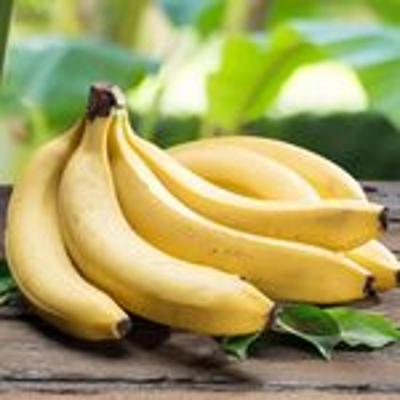

In [39]:
img = Image.open('banana.jpg')
img.resize((400, 400))

In [40]:
img_tensor = classifier.image_encoder.val_preprocess(img).unsqueeze(0)
img_tensor.shape

torch.Size([1, 3, 224, 224])

In [41]:
with torch.no_grad():
    logits = classifier(img_tensor.to(device))
    probs = logits.softmax(dim=-1).squeeze()

values, indices = probs.sort(descending=True)
for val, ind in zip(values, indices):
    print(f'Class {classnames[ind.item()]}: {val.item() * 100:.2f}%')

Class banana: 99.59%
Class lemon: 0.25%
Class mango: 0.12%
Class apple: 0.02%
Class orange: 0.01%
Class grapes: 0.01%
Class kiwi: 0.00%
Class tomato: 0.00%


## Download CIFAR-10.1 and CIFAR-10.2 datasets

In [ ]:
%%bash
mkdir -p ./datasets
export DATA_LOCATION=./datasets

# CIFAR10.1
mkdir -p $DATA_LOCATION/CIFAR-10.1
wget https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v6_data.npy -P $DATA_LOCATION/CIFAR-10.1
wget https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v6_labels.npy -P $DATA_LOCATION/CIFAR-10.1

# CIFAR10.2
mkdir -p $DATA_LOCATION/CIFAR-10.2
wget https://github.com/modestyachts/cifar-10.2/raw/61b0e3ac09809a2351379fb54331668cc9c975c4/cifar102_test.npy -P $DATA_LOCATION/CIFAR-10.2
wget https://github.com/modestyachts/cifar-10.2/raw/61b0e3ac09809a2351379fb54331668cc9c975c4/cifar102_train.npy -P $DATA_LOCATION/CIFAR-10.2

## Fine-tune model and create a weight ensemble

### Linear probing + weight ensemble

In [4]:
!python wise_ft.py   \
    --train-dataset=CIFAR10  \
    --epochs=10  \
    --lr=1e-3  \
    --batch-size=128  \
    --cache-dir=cache  \
    --model=ViT-B/32  \
    --freeze-encoder  \
    --eval-datasets=CIFAR10,CIFAR101,CIFAR102,STL10  \
    --template=simple_template  \
    --results-db=results_lp.json  \
    --save=models/wiselp/ViTB32  \
    --data-location=./datasets \
    --alpha 0 0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.0

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Getting zeroshot weights.
100% 10/10 [00:00<00:00, 51.57it/s]
Saving image classifier to models/wiselp/ViTB32/zeroshot.pt
Loading image classifier from models/wiselp/ViTB32/zeroshot.pt
Fine-tuning a linear classifier
Using devices [0]
Getting features from cache/CIFAR10/train
Train Epoch: 0 [0% 0/391]	Loss: 0.473438	Data (t) 0.000	Batch (t) 0.056
Saving model to models/wiselp/ViTB32/finetuned/checkpoint_1.pt
Saving image classifier to models/wiselp/ViTB32/finetuned/checkpoint_1.pt
Evaluating on CIFAR10
Getting features from cache/CIFAR10/

In [5]:
!python scatter_plot.py  \
    --train-dataset=CIFAR10  \
    --eval-datasets=CIFAR101,CIFAR102,STL10  \
    --results-db=results_lp.json  \
    --save plots_lp

### Results for CIFAR-10.1

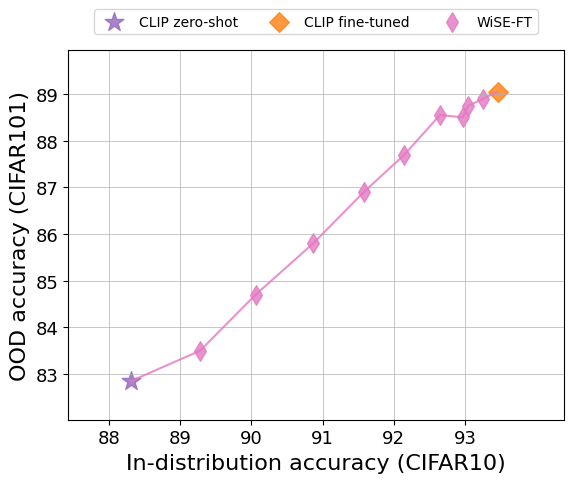

In [8]:
Image.open('plots_lp/CIFAR101.png')

### Results for CIFAR-10.2

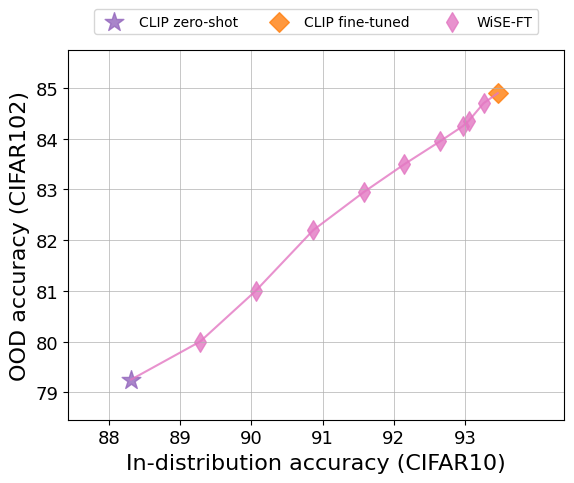

In [9]:
Image.open('plots_lp/CIFAR102.png')

### Results for STL-10

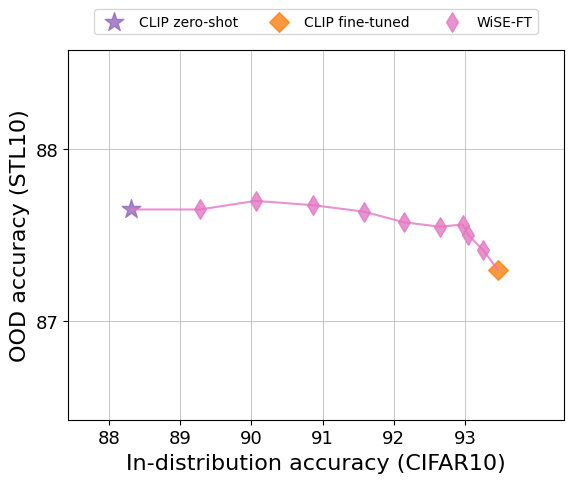

In [10]:
Image.open('plots_lp/STL10.png')

### Full fine-tuning + weight ensemble

In [11]:
!python wise_ft.py   \
    --train-dataset=CIFAR10  \
    --epochs=1  \
    --lr=5e-6  \
    --batch-size=64  \
    --cache-dir=cache  \
    --model=ViT-B/32  \
    --eval-datasets=CIFAR10,CIFAR101,CIFAR102,STL10  \
    --template=simple_template  \
    --results-db=results_ft.json  \
    --save=models/wiseft/ViTB32  \
    --data-location=./datasets \
    --alpha 0 0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.0

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Getting zeroshot weights.
100% 10/10 [00:00<00:00, 63.73it/s]
Saving image classifier to models/wiseft/ViTB32/zeroshot.pt
Loading image classifier from models/wiseft/ViTB32/zeroshot.pt
Fine-tuning end-to-end
Using devices [0]
Train Epoch: 0 [0% 0/782]	Loss: 0.503517	Data (t) 0.082	Batch (t) 2.701
Train Epoch: 0 [13% 100/782]	Loss: 0.097811	Data (t) 0.522	Batch (t) 0.555
Train Epoch: 0 [26% 200/782]	Loss: 0.038741	Data (t) 0.525	Batch (t) 0.562
Train Epoch: 0 [38% 300/782]	Loss: 0.106875	Data (t) 0.531	Batch (t) 0.563
Train Epoch: 0 [51% 4

In [12]:
!python scatter_plot.py  \
    --train-dataset=CIFAR10  \
    --eval-datasets=CIFAR101,CIFAR102,STL10  \
    --results-db=results_ft.json  \
    --save plots_ft

### Results for CIFAR-10.1

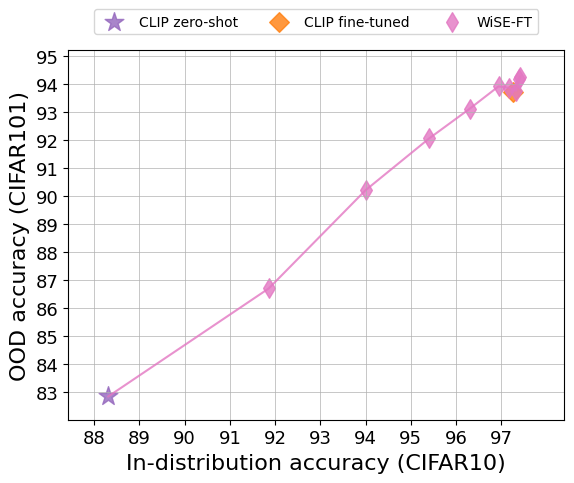

In [13]:
Image.open('plots_ft/CIFAR101.png')

### Results for CIFAR-10.2

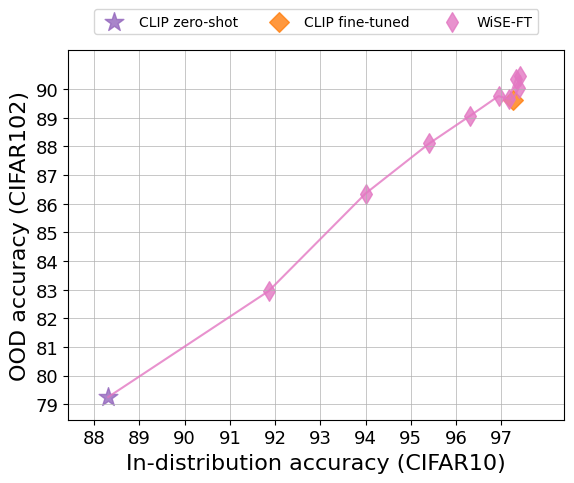

In [16]:
Image.open('plots_ft/CIFAR102.png')

### Results for STL-10

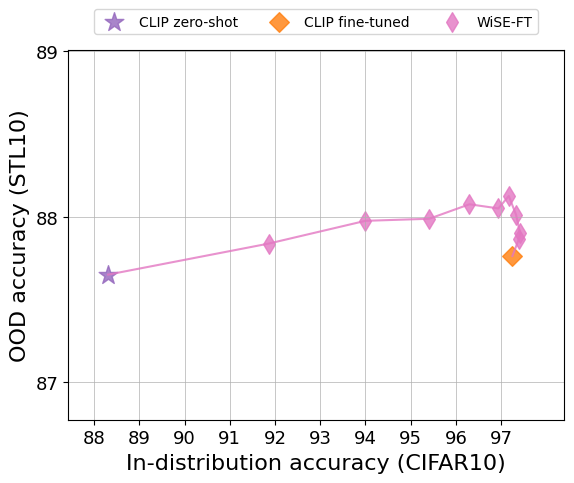

In [15]:
Image.open('plots_ft/STL10.png')